In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
pd.read_csv("/content/Ecommerce_Delivery.csv.csv")

,Order ID,Customer ID,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
0,ORD000001,CUST2824,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No
1,ORD000002,CUST1409,Blinkit,54:29.5,16,Dairy,279,Quick and reliable!,5,No,No
2,ORD000003,CUST5506,JioMart,21:29.5,25,Beverages,599,Items missing from order.,2,No,Yes
3,ORD000004,CUST5012,JioMart,19:29.5,42,Beverages,946,Items missing from order.,2,Yes,Yes
4,ORD000005,CUST4657,Blinkit,49:29.5,30,Beverages,334,"Fast delivery, great service!",5,No,No
...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD099996,CUST5324,JioMart,49:29.5,24,Dairy,289,Packaging could be better.,3,No,No
99996,ORD099997,CUST1677,JioMart,18:29.5,19,Snacks,322,Good quality products.,4,No,No
99997,ORD099998,CUST8198,JioMart,27:29.5,41,Dairy,135,"Fast delivery, great service!",5,Yes,No
99998,ORD099999,CUST9975,JioMart,14:29.5,31,Grocery,973,Quick and reliable!,5,No,No


In [4]:
df = pd.read_csv("/content/Ecommerce_Delivery.csv.csv")

print("First 5 rows of the dataset:")
print(df.head())

print("\nDataFrame Information:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe(include='all'))

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows of the dataset:
    Order ID Customer ID Platform Order Date & Time  Delivery Time (Minutes)  \
0  ORD000001    CUST2824  JioMart           19:29.5                       30   
1  ORD000002    CUST1409  Blinkit           54:29.5                       16   
2  ORD000003    CUST5506  JioMart           21:29.5                       25   
3  ORD000004    CUST5012  JioMart           19:29.5                       42   
4  ORD000005    CUST4657  Blinkit           49:29.5                       30   

      Product Category  Order Value (INR)              Customer Feedback  \
0  Fruits & Vegetables                382  Fast delivery, great service!   
1                Dairy                279            Quick and reliable!   
2            Beverages                599      Items missing from order.   
3            Beverages                946      Items missing from order.   
4            Beverages                334  Fast delivery, great service!   

   Service Rating Delivery Delay 

In [5]:
seen_columns = set()
duplicate_columns = []

for col in df.columns:
    if col in seen_columns:
        duplicate_columns.append(col)
    else:
        seen_columns.add(col)

if duplicate_columns:
    df = df.loc[:, ~df.columns.duplicated()]
    print(f"Dropped duplicate columns: {duplicate_columns}")
else:
    print("No duplicate columns found.")

print("\nUpdated DataFrame columns:")
print(df.columns)

No duplicate columns found.

Updated DataFrame columns:
Index(['Order ID', 'Customer ID', 'Platform', 'Order Date & Time',
       'Delivery Time (Minutes)', 'Product Category', 'Order Value (INR)',
       'Customer Feedback', 'Service Rating', 'Delivery Delay',
       'Refund Requested'],
      dtype='object')


In [6]:
print("\nUnique values and counts for key categorical columns:")

categorical_cols = ['Platform', 'Product Category', 'Customer Feedback', 'Service Rating', 'Delivery Delay', 'Refund Requested']

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())



Unique values and counts for key categorical columns:

--- Platform ---
Platform
Swiggy Instamart    33449
Blinkit             33424
JioMart             33127
Name: count, dtype: int64

--- Product Category ---
Product Category
Dairy                  16857
Grocery                16737
Snacks                 16705
Fruits & Vegetables    16632
Beverages              16536
Personal Care          16533
Name: count, dtype: int64

--- Customer Feedback ---
Customer Feedback
Easy to order, loved it!                      7791
Good quality products.                        7789
Excellent experience!                         7784
Very satisfied with the service.              7740
Wrong item delivered.                         7738
Items missing from order.                     7737
Fast delivery, great service!                 7715
Packaging could be better.                    7704
Quick and reliable!                           7658
Delivery person was rude.                     7643
Very late delive

In [7]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

print("\n--- Numerical Column Statistics ---")
for col in numerical_cols:
    print(f"\nColumn: {col}")
    print(f"  Mean: {np.mean(df[col]):.2f}")
    print(f"  Median: {np.median(df[col]):.2f}")
    print(f"  Standard Deviation: {np.std(df[col]):.2f}")
    # Using pandas .mode() as NumPy does not have a direct mode function
    mode_val = df[col].mode().tolist()
    print(f"  Mode: {mode_val}")

print("\n--- Categorical Column Statistics ---")
for col in categorical_cols:
    # Exclude 'Order ID' and 'Customer ID' as they are identifiers
    if col in ['Order ID', 'Customer ID', 'Order Date & Time']:
        continue
    print(f"\nColumn: {col}")
    # Mean, Median, Standard Deviation are not applicable to categorical data
    print("  Mean: Not applicable to categorical data")
    print("  Median: Not applicable to categorical data")
    print("  Standard Deviation: Not applicable to categorical data")
    # Using pandas .mode() as NumPy does not have a direct mode function
    mode_val = df[col].mode().tolist()
    print(f"  Mode: {mode_val}")



--- Numerical Column Statistics ---

Column: Delivery Time (Minutes)
  Mean: 29.54
  Median: 30.00
  Standard Deviation: 9.96
  Mode: [31]

Column: Order Value (INR)
  Mean: 590.99
  Median: 481.00
  Standard Deviation: 417.41
  Mode: [219]

Column: Service Rating
  Mean: 3.24
  Median: 3.00
  Standard Deviation: 1.58
  Mode: [5]

--- Categorical Column Statistics ---

Column: Platform
  Mean: Not applicable to categorical data
  Median: Not applicable to categorical data
  Standard Deviation: Not applicable to categorical data
  Mode: ['Swiggy Instamart']

Column: Product Category
  Mean: Not applicable to categorical data
  Median: Not applicable to categorical data
  Standard Deviation: Not applicable to categorical data
  Mode: ['Dairy']

Column: Customer Feedback
  Mean: Not applicable to categorical data
  Median: Not applicable to categorical data
  Standard Deviation: Not applicable to categorical data
  Mode: ['Easy to order, loved it!']

Column: Delivery Delay
  Mean: Not ap

In [8]:
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

print("Correlation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                         Delivery Time (Minutes)  Order Value (INR)  \
Delivery Time (Minutes)                 1.000000           0.007225   
Order Value (INR)                       0.007225           1.000000   
Service Rating                          0.000136          -0.002689   

                         Service Rating  
Delivery Time (Minutes)        0.000136  
Order Value (INR)             -0.002689  
Service Rating                 1.000000  


### Visualization of the Correlation Matrix

Let's visualize the correlation matrix using a heatmap to easily identify strong positive or negative correlations between numerical features.

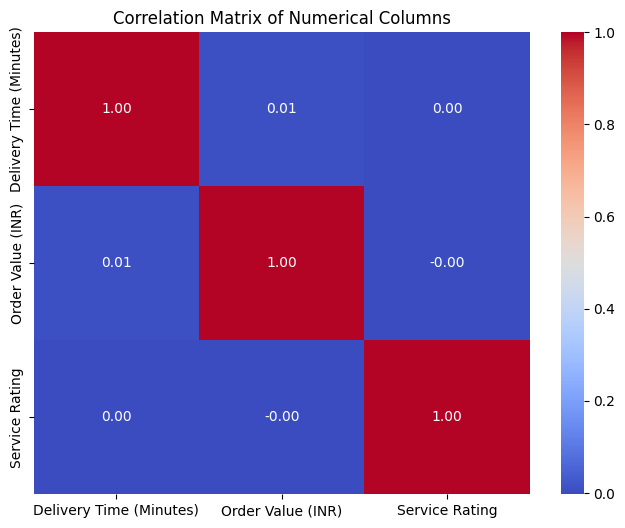

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Columns')
plt.show()


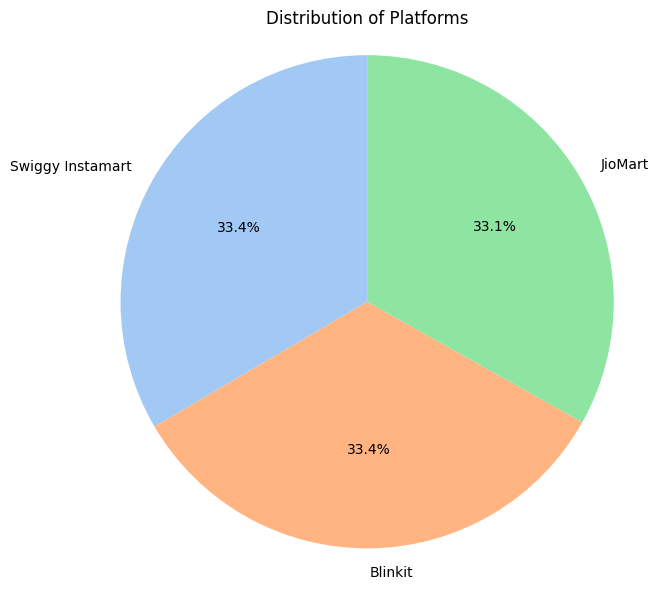

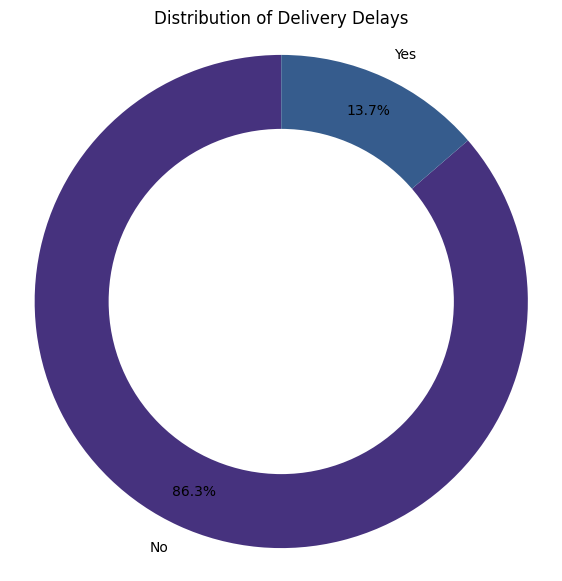

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Univariate Analysis for 'Platform' using a Pie Chart
platform_counts = df['Platform'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(platform_counts, labels=platform_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Platforms')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Univariate Analysis for 'Delivery Delay' using a Donut Chart
delay_counts = df['Delivery Delay'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(delay_counts, labels=delay_counts.index, autopct='%1.1f%%', startangle=90, pctdistance=0.85, colors=sns.color_palette('viridis'))

# Draw a circle in the middle to make it a donut chart
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Delivery Delays')
plt.axis('equal')
plt.show()


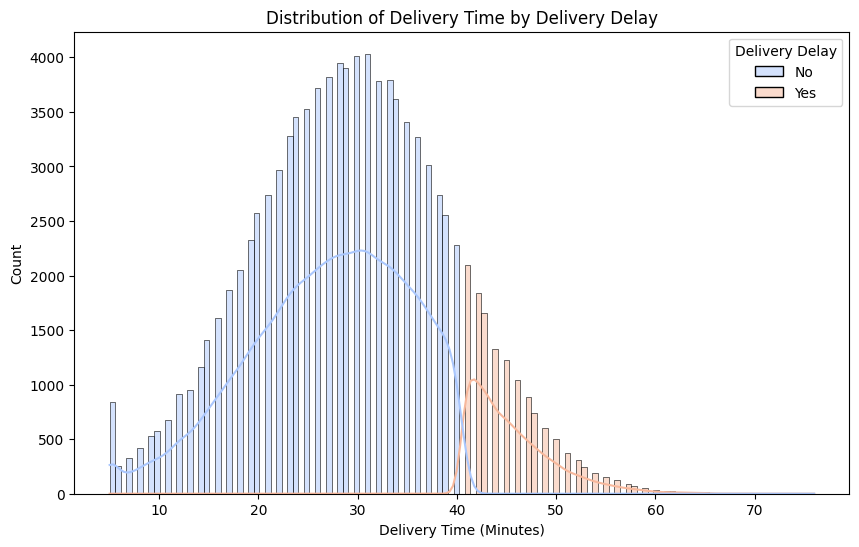

/tmp/ipykernel_539/3438590404.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Platform', y='Order Value (INR)', palette='viridis')


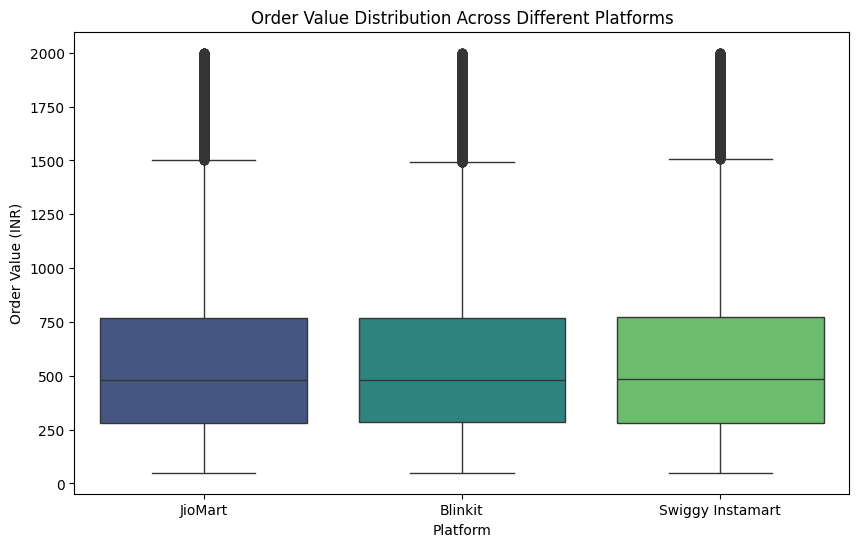

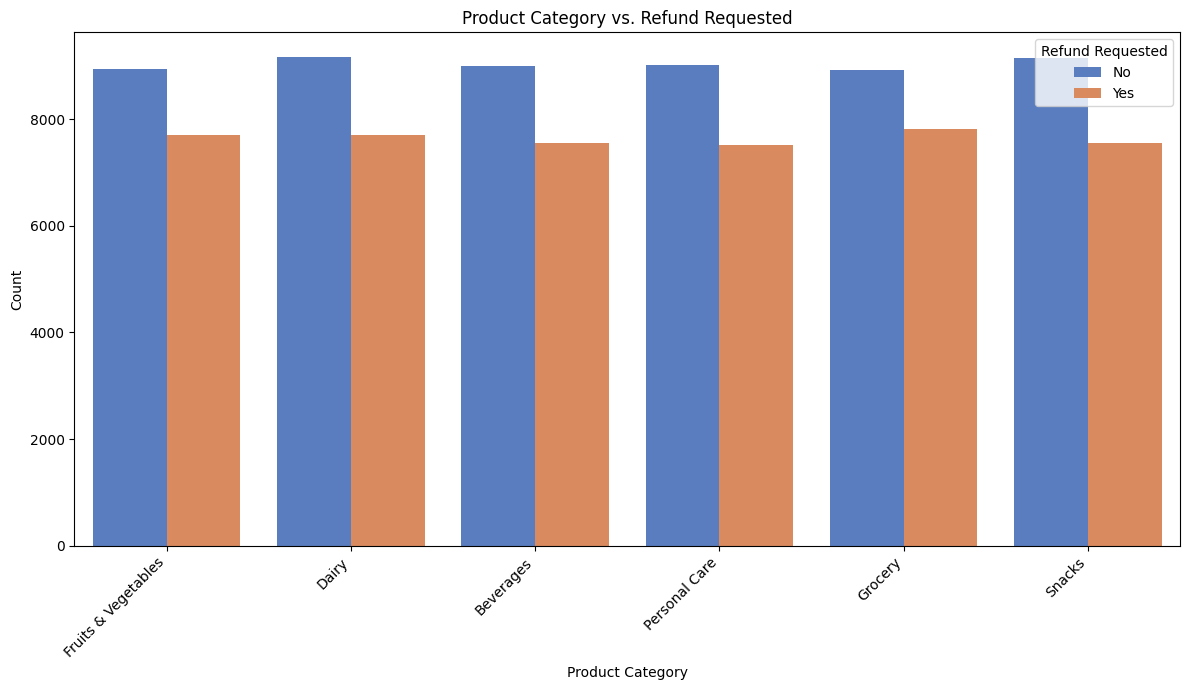

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bivariate Analysis 1: Histogram for Delivery Time (Minutes) by Delivery Delay
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Delivery Time (Minutes)', hue='Delivery Delay', kde=True, palette='coolwarm')
plt.title('Distribution of Delivery Time by Delivery Delay')
plt.xlabel('Delivery Time (Minutes)')
plt.ylabel('Count')
plt.show()

# Bivariate Analysis 2: Box Plot for Order Value (INR) by Platform
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Platform', y='Order Value (INR)', palette='viridis')
plt.title('Order Value Distribution Across Different Platforms')
plt.xlabel('Platform')
plt.ylabel('Order Value (INR)')
plt.show()

# Bivariate Analysis 3: Grouped Bar Chart (Count Plot) for Product Category vs. Refund Requested
# An area line chart is typically used for trends over time or ordered numerical categories.
# For two categorical variables, a grouped bar chart (count plot) is more appropriate for bivariate analysis.
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='Product Category', hue='Refund Requested', palette='muted')
plt.title('Product Category vs. Refund Requested')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
